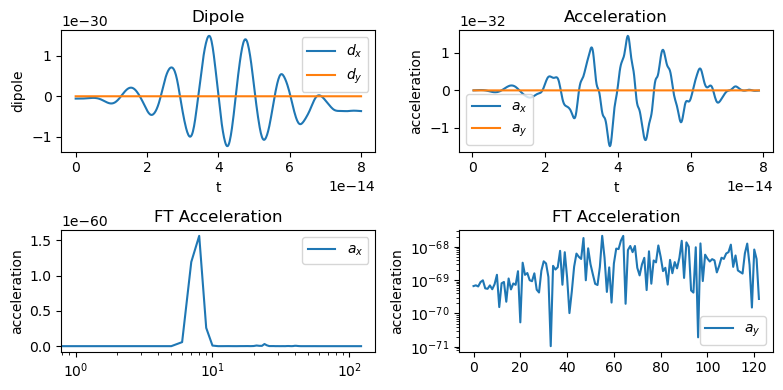

In [2]:
import numpy as np
import matplotlib.pyplot as plt
#plt.style.use('/home/lplaja/.matplotlib/stylelib/obsidian.mplstyle')

t = []
dipole_x = []
dipole_y = []

filename='graphene_bilayerAA_pruebark_dipole.txt'
with open(filename, "r") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        it, ix, iy = map(complex, line.split())
        t.append(np.real(it))
        dipole_x.append(ix)
        dipole_y.append(iy)
    
accel_x=np.gradient(np.gradient(np.real(dipole_x)))
accel_y=np.gradient(np.gradient(np.real(dipole_y)))
accel_x=accel_x[2:-3]
accel_y=accel_y[2:-3]

nfilter=accel_x.shape[0]//5
i_filter=np.linspace(0,nfilter,nfilter)
filter=np.ones(accel_x.shape[0])
filter[-nfilter:]*=np.exp(-i_filter**2/10000)

accel_x*=filter
accel_y*=filter

FT_npts=2*accel_x.shape[0]//8
FT_accel_x=np.fft.fft(accel_x)[:FT_npts]
FT_accel_y=np.fft.fft(accel_y)[:FT_npts]


fig, ax=plt.subplots(2,2, figsize=(8,4))

ax[0,0].plot(t, np.real(dipole_x), label="$d_x$")
ax[0,0].plot(t, np.real(dipole_y), label="$d_y$")
ax[0,0].set_xlabel("t")
ax[0,0].set_ylabel("dipole")
ax[0,0].set_title("Dipole")
ax[0,0].legend()
ax[0,0].grid(False)

ax[0,1].plot(t[2:-3], np.real(accel_x), label="$a_x$")
ax[0,1].plot(t[2:-3], np.real(accel_y), label="$a_y$")
ax[0,1].set_xlabel("t")
ax[0,1].set_ylabel("acceleration")
ax[0,1].set_title("Acceleration")
ax[0,1].legend()
ax[0,1].grid(False)

ax[1,0].semilogx(np.abs(FT_accel_x)**2, label="$a_x$")
ax[1,0].set_xlabel("")
ax[1,0].set_ylabel("acceleration")
ax[1,0].set_title("FT Acceleration")
ax[1,0].legend()
ax[1,0].grid(False)

ax[1,1].semilogy(np.abs(FT_accel_y)**2, label="$a_y$")
ax[1,1].set_xlabel("")
ax[1,1].set_ylabel("acceleration")
ax[1,1].set_title("FT Acceleration")
ax[1,1].legend()
# ax[1,1].set_ylim(1e-67,1e-59)
ax[1,1].grid(False)

plt.tight_layout()

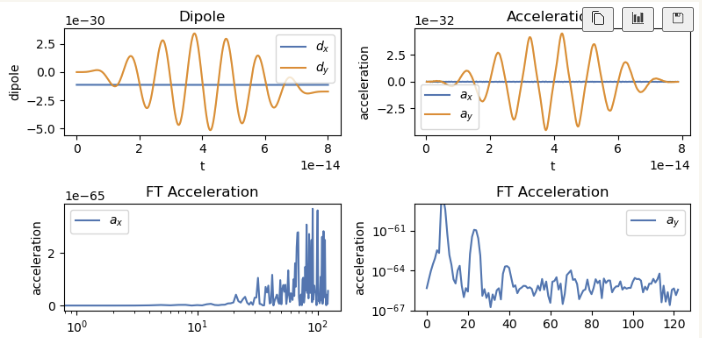

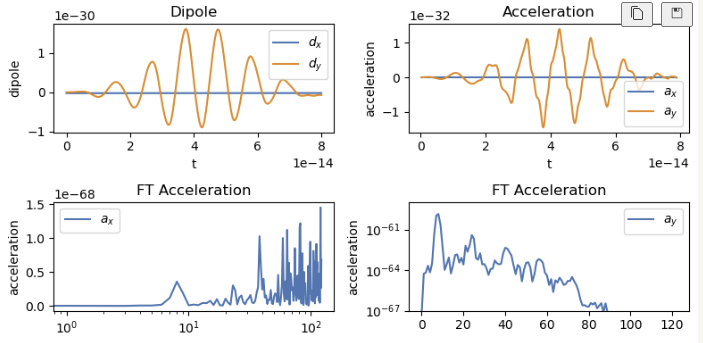

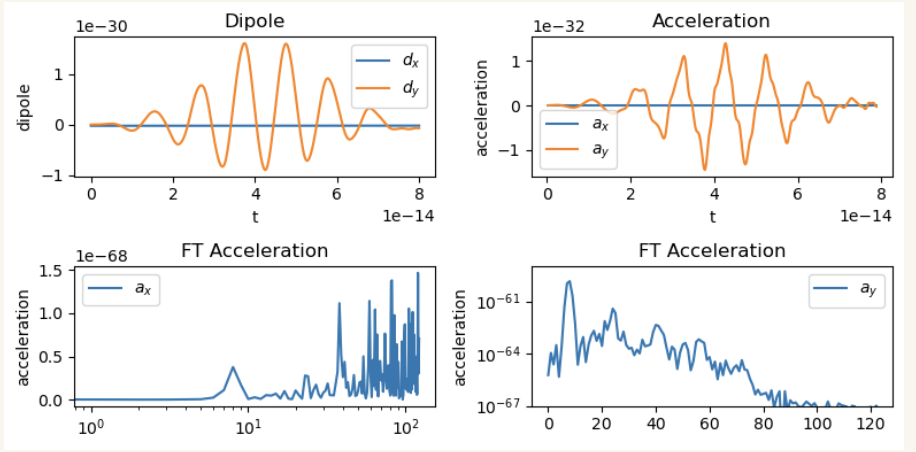

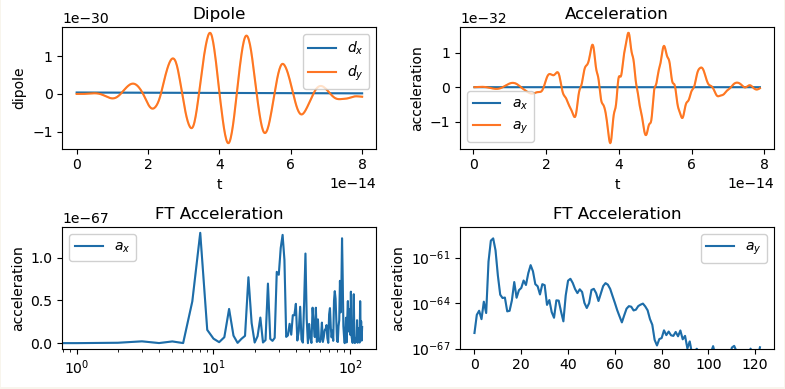

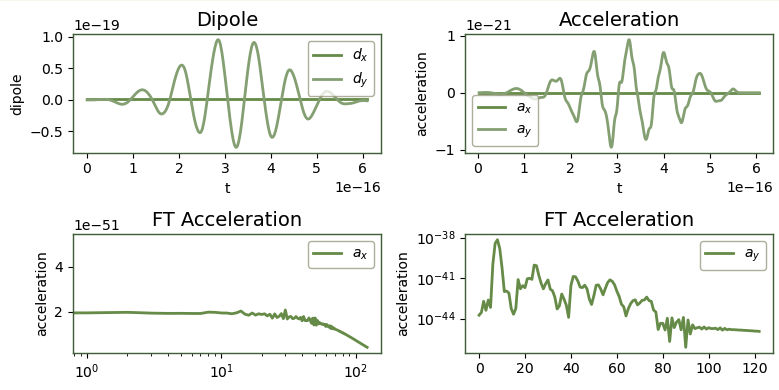